In [1]:
# ============================================================
# IMPORTS - All libraries we need
# ============================================================
import os
import pickle
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from torch.nn.functional import cosine_similarity

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
# ============================================================
# STEP 1: SCAN DATASET FOLDER
# Get all audio file paths and their speaker labels
# ============================================================

DATASET_PATH = "vox1_indian"  # Your dataset folder

file_paths = []   # List of all .wav file paths
labels = []       # Corresponding speaker name for each file

# Walk through each speaker folder
for speaker_name in os.listdir(DATASET_PATH):
    speaker_folder = os.path.join(DATASET_PATH, speaker_name)
    
    if os.path.isdir(speaker_folder):
        for audio_file in os.listdir(speaker_folder):
            if audio_file.endswith(".wav"):
                full_path = os.path.join(speaker_folder, audio_file)
                file_paths.append(full_path)
                labels.append(speaker_name)

print(f"Total audio files found: {len(file_paths)}")
print(f"Speakers found: {set(labels)}")
print(f"Number of speakers: {len(set(labels))}")

Total audio files found: 572
Speakers found: {'Amitabh_Bachchan', 'Irrfan_Khan', 'Kangana_Ranaut', 'John_Abraham', 'Parineeti_Chopra', 'Akshay_Kumar', 'Vidya_Balan', 'Sonam_Kapoor', 'Tabu', 'Mallika_Sherawat', 'Shraddha_Kapoor', 'Pooja_Kumar', 'Shahid_Kapoor', 'Randeep_Hooda', 'Preity_Zinta', 'Om_Puri', 'Freida_Pinto', 'Ranbir_Kapoor', 'Aamir_Khan', 'Sidharth_Malhotra', 'Suraj_Sharma', 'Ajay_Devgn', 'Naseeruddin_Shah'}
Number of speakers: 23


In [4]:
# ============================================================
# STEP 2: ENCODE SPEAKER NAMES TO NUMBERS
# ML models need numbers, not strings
# Example: "Amitabh_Bachchan" -> 0, "Aamir_Khan" -> 1
# ============================================================

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

NUM_CLASSES = len(label_encoder.classes_)
print(f"Speaker classes: {label_encoder.classes_}")
print(f"Encoded labels: {encoded_labels[:10]}")
print(f"Number of classes: {NUM_CLASSES}")

Speaker classes: ['Aamir_Khan' 'Ajay_Devgn' 'Akshay_Kumar' 'Amitabh_Bachchan'
 'Freida_Pinto' 'Irrfan_Khan' 'John_Abraham' 'Kangana_Ranaut'
 'Mallika_Sherawat' 'Naseeruddin_Shah' 'Om_Puri' 'Parineeti_Chopra'
 'Pooja_Kumar' 'Preity_Zinta' 'Ranbir_Kapoor' 'Randeep_Hooda'
 'Shahid_Kapoor' 'Shraddha_Kapoor' 'Sidharth_Malhotra' 'Sonam_Kapoor'
 'Suraj_Sharma' 'Tabu' 'Vidya_Balan']
Encoded labels: [0 0 0 0 0 0 0 0 0 0]
Number of classes: 23


In [5]:
# ============================================================
# STEP 3: TRAIN/TEST SPLIT (80% train, 20% test)
# Split at FILE level (not speaker level)
# ============================================================

train_files, test_files, train_labels, test_labels = train_test_split(
    file_paths,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels  # Equal representation of each speaker
)

print(f"Training files: {len(train_files)}")
print(f"Testing files:  {len(test_files)}")

Training files: 457
Testing files:  115


In [6]:
# ============================================================
# STEP 4: AUDIO -> LOG-MEL SPECTROGRAM FUNCTION
# This converts raw audio into a 2D image-like representation
# Shape: (128 bins x 128 time frames)
# ============================================================

def audio_to_melspectrogram(file_path, sample_rate=16000, n_mels=128, fixed_length=128):
    """
    Loads a .wav file and converts it to a log-mel spectrogram.
    
    Steps:
    1. Load audio, convert to mono, resample to 16kHz
    2. Compute mel spectrogram (128 frequency bins)
    3. Convert to log scale (dB)
    4. Pad or trim to fixed 128x128 size
    """
    
    # Load audio: mono=True converts stereo to mono, sr resamples to 16kHz
    audio, sr = librosa.load(file_path, sr=sample_rate, mono=True)
    
    # Compute mel spectrogram
    # n_fft: FFT window size, hop_length: step size between windows
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        n_fft=512,
        hop_length=256
    )
    
    # Convert to log scale (decibels) - makes features more perceptible
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Pad or trim the time dimension to fixed_length (128 frames)
    if log_mel_spec.shape[1] < fixed_length:
        # PAD: add zeros on the right if audio is too short
        pad_width = fixed_length - log_mel_spec.shape[1]
        log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, pad_width)), mode='constant')
    else:
        # TRIM: cut from the right if audio is too long
        log_mel_spec = log_mel_spec[:, :fixed_length]
    
    # Final shape: (128, 128) -> frequency x time
    return log_mel_spec.astype(np.float32)

# Quick test
test_spec = audio_to_melspectrogram(file_paths[0])
print(f"Spectrogram shape: {test_spec.shape}")  # Should be (128, 128)

C:\Users\ARYAN SINGH JADAUN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Spectrogram shape: (128, 128)


In [7]:
# ============================================================
# STEP 5: PYTORCH DATASET CLASS WITH DATA AUGMENTATION
# PyTorch needs data in a special format
# SpecAugment to prevent overfitting with small dataset
# ============================================================

def augment_spectrogram(spec):
    """
    Apply SpecAugment: mask random time and frequency regions
    ESSENTIAL for small datasets (20-25 speakers) to prevent overfitting
    """
    spec = spec.clone()
    
    # TIME MASKING: mask random consecutive time frames
    if np.random.rand() > 0.5:
        time_mask_width = np.random.randint(5, 20)
        time_start = np.random.randint(0, max(1, spec.shape[2] - time_mask_width))
        spec[:, :, time_start:time_start+time_mask_width] = -80
    
    # FREQUENCY MASKING: mask random consecutive frequency bins
    if np.random.rand() > 0.5:
        freq_mask_width = np.random.randint(5, 20)
        freq_start = np.random.randint(0, max(1, spec.shape[1] - freq_mask_width))
        spec[:, freq_start:freq_start+freq_mask_width, :] = -80
    
    return spec


class SpeakerDataset(Dataset):
    def __init__(self, file_paths, labels, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        label = self.labels[index]
        
        spectrogram = audio_to_melspectrogram(file_path)
        spectrogram = torch.tensor(spectrogram).unsqueeze(0)
        
        # Apply augmentation only to training data
        if self.augment:
            spectrogram = augment_spectrogram(spectrogram)
        
        return spectrogram, torch.tensor(label, dtype=torch.long)


# Create Dataset objects with augmentation for training
train_dataset = SpeakerDataset(train_files, train_labels, augment=True)
test_dataset  = SpeakerDataset(test_files, test_labels, augment=False)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print("✓ SpecAugment enabled for small dataset training!")

Train batches: 29
Test batches:  8
Batch shape: torch.Size([16, 1, 128, 128])
Labels shape: torch.Size([16])
✓ SpecAugment enabled for small dataset training!


In [8]:
# ============================================================
# STEP 6: CNN MODEL ARCHITECTURE
#
# Architecture:
#   Input: (batch, 1, 128, 128) - grayscale spectrogram
#   3x Conv Block (Conv2D + ReLU + MaxPool)
#   Global Average Pooling
#   Embedding Layer (256-d)
#   Classification Head (256 -> num_speakers)
# ============================================================

class SpeakerCNN(nn.Module):
    def __init__(self, num_classes, embedding_dim=256):
        super(SpeakerCNN, self).__init__()
        
        # ----- CONV BLOCK 1 -----
        # Input: (1, 128, 128) -> Output: (32, 64, 64)
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Halves spatial dimensions
        )
        
        # ----- CONV BLOCK 2 -----
        # Input: (32, 64, 64) -> Output: (64, 32, 32)
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # ----- CONV BLOCK 3 -----
        # Input: (64, 32, 32) -> Output: (128, 16, 16)
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # ----- GLOBAL AVERAGE POOLING -----
        # Reduces (128, 16, 16) -> (128, 1, 1) -> then flatten to (128,)
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # ----- EMBEDDING LAYER -----
        # 128 -> 256 dimensional speaker embedding
        self.embedding_layer = nn.Linear(128, embedding_dim)
        
        # ----- CLASSIFICATION HEAD -----
        # 256 -> number of speakers
        self.classifier = nn.Linear(embedding_dim, num_classes)
    
    def forward(self, x):
        # Pass through 3 conv blocks
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        
        # Global average pooling
        x = self.global_avg_pool(x)
        
        # Flatten: (batch, 128, 1, 1) -> (batch, 128)
        x = x.view(x.size(0), -1)
        
        # Get 256-d embedding
        embedding = torch.relu(self.embedding_layer(x))
        
        # Get final class scores
        output = self.classifier(embedding)
        
        return output, embedding  # Return both for flexibility


# Create model and move to GPU if available
model = SpeakerCNN(num_classes=NUM_CLASSES, embedding_dim=256).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SpeakerCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_avg_pool): AdaptiveAvgPool2d(output_size=1)
  (embedding_layer): Linear(in_features=128, out_features=256, bias=True)
  (classifier): Linear(in_features=256, out_features=23, bias=True)
)

Total parameters: 131,607


In [9]:
# ============================================================
# STEP 7: TRAINING SETUP (OPTIMIZED FOR SMALL DATASET)
# Lower epochs + learning rate decay to prevent overfitting
# ============================================================

criterion = nn.CrossEntropyLoss()

# Lower learning rate with decay
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# For 20-25 speakers: use 30 epochs with early stopping potential
NUM_EPOCHS = 30

print(f"✓ Training config optimized for {len(set(labels))} speakers")
print(f"  - Epochs: {NUM_EPOCHS} (not 50 - prevents overfitting)")
print(f"  - Learning Rate: 0.0005 (slow, careful learning)")
print(f"  - SpecAugment: Enabled (artificial data expansion)")
print(f"  - Batch Size: 16 (stable gradients)")

✓ Training config optimized for 23 speakers
  - Epochs: 30 (not 50 - prevents overfitting)
  - Learning Rate: 0.0005 (slow, careful learning)
  - SpecAugment: Enabled (artificial data expansion)
  - Batch Size: 16 (stable gradients)


In [ ]:
# ============================================================
# STEP 8: TRAINING LOOP
# Train for NUM_EPOCHS, print accuracy each epoch
# ============================================================

train_acc_history = []
val_acc_history   = []

for epoch in range(NUM_EPOCHS):
    
    # ---- TRAINING PHASE ----
    model.train()  # Set model to training mode (enables dropout, batch norm etc.)
    correct_train = 0
    total_train   = 0
    
    for spectrograms, labels in train_loader:
        # Move data to GPU if available
        spectrograms = spectrograms.to(device)
        labels       = labels.to(device)
        
        # Forward pass: get predictions
        outputs, _ = model(spectrograms)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass: compute gradients
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()        # Compute new gradients
        optimizer.step()       # Update weights
        
        # Count correct predictions
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train   += labels.size(0)
    
    train_accuracy = 100 * correct_train / total_train
    
    # ---- VALIDATION PHASE ----
    model.eval()  # Set model to eval mode (disables dropout etc.)
    correct_val = 0
    total_val   = 0
    
    with torch.no_grad():  # No gradient computation needed during evaluation
        for spectrograms, labels in test_loader:
            spectrograms = spectrograms.to(device)
            labels       = labels.to(device)
            
            outputs, _ = model(spectrograms)
            
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val   += labels.size(0)
    
    val_accuracy = 100 * correct_val / total_val
    
    # Save history
    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)
    
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")

print("\nTraining Complete!")

Epoch [ 1/30] | Train Acc: 7.22% | Val Acc: 9.57%
Epoch [ 2/30] | Train Acc: 7.44% | Val Acc: 9.57%
Epoch [ 3/30] | Train Acc: 7.66% | Val Acc: 9.57%
Epoch [ 4/30] | Train Acc: 10.28% | Val Acc: 9.57%
Epoch [ 5/30] | Train Acc: 10.50% | Val Acc: 17.39%
Epoch [ 6/30] | Train Acc: 16.41% | Val Acc: 16.52%
Epoch [ 7/30] | Train Acc: 19.04% | Val Acc: 30.43%
Epoch [ 8/30] | Train Acc: 24.95% | Val Acc: 17.39%
Epoch [ 9/30] | Train Acc: 24.51% | Val Acc: 24.35%
Epoch [10/30] | Train Acc: 28.23% | Val Acc: 30.43%
Epoch [11/30] | Train Acc: 30.85% | Val Acc: 35.65%
Epoch [12/30] | Train Acc: 35.89% | Val Acc: 39.13%
Epoch [13/30] | Train Acc: 42.89% | Val Acc: 42.61%
Epoch [14/30] | Train Acc: 45.08% | Val Acc: 40.87%
Epoch [15/30] | Train Acc: 46.61% | Val Acc: 38.26%
Epoch [16/30] | Train Acc: 51.42% | Val Acc: 47.83%
Epoch [17/30] | Train Acc: 51.86% | Val Acc: 56.52%
Epoch [18/30] | Train Acc: 55.80% | Val Acc: 49.57%
Epoch [19/30] | Train Acc: 55.14% | Val Acc: 57.39%
Epoch [20/30] | Tra

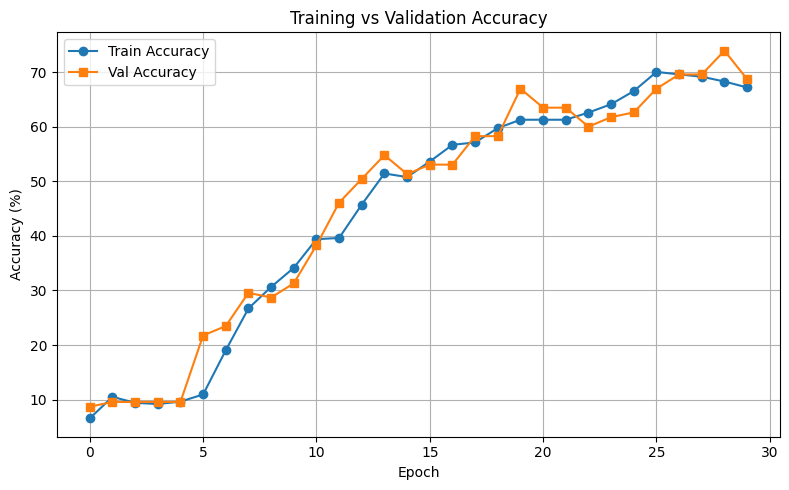

In [ ]:
# ============================================================
# PLOT TRAINING ACCURACY OVER EPOCHS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label="Train Accuracy", marker='o')
plt.plot(val_acc_history,   label="Val Accuracy",   marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 9: SAVE MODEL WEIGHTS
# Save the trained model so we can reload it later
# ============================================================

torch.save(model.state_dict(), "model.pth")
print("Model saved as model.pth")

Model saved as model.pth


In [ ]:
# ============================================================
# STEP 10: BUILD SPEAKER EMBEDDING DATABASE
# 
# How it works:
# 1. Remove classification head (use only embedding layer)
# 2. Pass ALL audio files through model
# 3. For each speaker, average their embeddings
# 4. Save as {speaker_name: embedding_vector} in voice_db.pkl
# ============================================================

def get_embedding(file_path, model, device):
    """
    Given a .wav file path, returns its 256-d embedding vector.
    """
    # Convert audio to spectrogram
    spec = audio_to_melspectrogram(file_path)
    
    # Add batch + channel dimensions: (128,128) -> (1, 1, 128, 128)
    spec_tensor = torch.tensor(spec).unsqueeze(0).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        _, embedding = model(spec_tensor)  # Get the 256-d embedding
    
    # Return as numpy array (1, 256) -> (256,)
    return embedding.squeeze(0).cpu().numpy()


# Build embedding database
# Structure: { "Amitabh_Bachchan": [list of 256-d vectors], ... }
speaker_embeddings = {}  # Temporarily holds all embeddings per speaker

print("Building speaker embedding database...")

for file_path, label_idx in zip(file_paths, encoded_labels):
    speaker_name = label_encoder.classes_[label_idx]
    
    embedding = get_embedding(file_path, model, device)
    
    if speaker_name not in speaker_embeddings:
        speaker_embeddings[speaker_name] = []
    
    speaker_embeddings[speaker_name].append(embedding)

# Average all embeddings per speaker to get one representative vector
voice_db = {}
for speaker_name, emb_list in speaker_embeddings.items():
    # Stack all embeddings and take mean -> shape: (256,)
    voice_db[speaker_name] = np.mean(np.stack(emb_list), axis=0)
    print(f"  {speaker_name}: averaged {len(emb_list)} embeddings")

# Save the voice database
with open("voice_db.pkl", "wb") as f:
    pickle.dump(voice_db, f)

print("\nVoice database saved as voice_db.pkl")
print(f"Database keys: {list(voice_db.keys())}")

Building speaker embedding database...
  Aamir_Khan: averaged 18 embeddings
  Ajay_Devgn: averaged 18 embeddings
  Akshay_Kumar: averaged 16 embeddings
  Amitabh_Bachchan: averaged 52 embeddings
  Freida_Pinto: averaged 12 embeddings
  Irrfan_Khan: averaged 53 embeddings
  John_Abraham: averaged 19 embeddings
  Kangana_Ranaut: averaged 43 embeddings
  Mallika_Sherawat: averaged 18 embeddings
  Naseeruddin_Shah: averaged 23 embeddings
  Om_Puri: averaged 21 embeddings
  Parineeti_Chopra: averaged 21 embeddings
  Pooja_Kumar: averaged 18 embeddings
  Preity_Zinta: averaged 43 embeddings
  Ranbir_Kapoor: averaged 30 embeddings
  Randeep_Hooda: averaged 13 embeddings
  Shahid_Kapoor: averaged 15 embeddings
  Shraddha_Kapoor: averaged 39 embeddings
  Sidharth_Malhotra: averaged 15 embeddings
  Sonam_Kapoor: averaged 20 embeddings
  Suraj_Sharma: averaged 26 embeddings
  Tabu: averaged 17 embeddings
  Vidya_Balan: averaged 22 embeddings

Voice database saved as voice_db.pkl
Database keys: [n

In [ ]:
# ============================================================
# STEP 11: SPEAKER IDENTIFICATION FUNCTION
# 
# Input : path to a .wav audio file
# Output: predicted speaker name, similarity score, status
#
# This function is reusable in a Flask/FastAPI backend!
# ============================================================

def identify_speaker(audio_path, model, voice_db, device, threshold=0.75):
    """
    Identifies the speaker in the given audio file using cosine similarity.
    
    Parameters:
        audio_path  : str  - path to the .wav file
        model       : trained SpeakerCNN model
        voice_db    : dict - {speaker_name: avg_embedding_vector}
        device      : torch device (cpu or cuda)
        threshold   : float - minimum similarity to accept (default: 0.75)
    
    Returns:
        dict with predicted_name, similarity_score, status
    """
    
    # Step 1: Get embedding of the input audio
    input_embedding = get_embedding(audio_path, model, device)
    input_tensor    = torch.tensor(input_embedding).unsqueeze(0)  # (1, 256)
    
    best_speaker    = None
    best_similarity = -1  # Cosine similarity ranges from -1 to 1
    
    # Step 2: Compare with each speaker in the database
    for speaker_name, db_embedding in voice_db.items():
        db_tensor = torch.tensor(db_embedding).unsqueeze(0)  # (1, 256)
        
        # Cosine similarity: 1 = identical, 0 = unrelated, -1 = opposite
        similarity = cosine_similarity(input_tensor, db_tensor).item()
        
        if similarity > best_similarity:
            best_similarity = similarity
            best_speaker    = speaker_name
    
    # Step 3: Apply threshold for authentication
    if best_similarity >= threshold:
        status = "Authenticated"
    else:
        status = "Voice Not Found"
        best_speaker = "Unknown"
    
    return {
        "predicted_name"  : best_speaker,
        "similarity_score": round(float(best_similarity), 4),
        "status"          : status
    }


print("identify_speaker() function is ready!")

identify_speaker() function is ready!


In [ ]:
# ============================================================
# HOW TO USE IN A BACKEND API (Example - Flask/FastAPI)
# 
# To reuse this in your Vercel backend:
# 1. Load model and voice_db once at startup
# 2. Call identify_speaker() per request
# ============================================================

# ---- Reload model from saved file (as would happen in backend) ----
loaded_model = SpeakerCNN(num_classes=NUM_CLASSES, embedding_dim=256).to(device)
loaded_model.load_state_dict(torch.load("model.pth", map_location=device))
loaded_model.eval()

# ---- Reload voice database ----
with open("voice_db.pkl", "rb") as f:
    loaded_voice_db = pickle.load(f)

print("Model and voice_db loaded successfully!")
print(f"Speakers in DB: {list(loaded_voice_db.keys())}")

Model and voice_db loaded successfully!
Speakers in DB: [np.str_('Aamir_Khan'), np.str_('Ajay_Devgn'), np.str_('Akshay_Kumar'), np.str_('Amitabh_Bachchan'), np.str_('Freida_Pinto'), np.str_('Irrfan_Khan'), np.str_('John_Abraham'), np.str_('Kangana_Ranaut'), np.str_('Mallika_Sherawat'), np.str_('Naseeruddin_Shah'), np.str_('Om_Puri'), np.str_('Parineeti_Chopra'), np.str_('Pooja_Kumar'), np.str_('Preity_Zinta'), np.str_('Ranbir_Kapoor'), np.str_('Randeep_Hooda'), np.str_('Shahid_Kapoor'), np.str_('Shraddha_Kapoor'), np.str_('Sidharth_Malhotra'), np.str_('Sonam_Kapoor'), np.str_('Suraj_Sharma'), np.str_('Tabu'), np.str_('Vidya_Balan')]


C:\Users\ARYAN SINGH JADAUN\AppData\Local\Temp\ipykernel_20628\1648240032.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("model

In [ ]:
# ============================================================
# FINAL TEST - Identify a speaker from a test audio file
# ============================================================

# Pick any test file to try identification
test_audio_path = test_files[7]
actual_label    = label_encoder.classes_[test_labels[7]]

print(f"Testing on : {test_audio_path}")
print(f"Actual speaker: {actual_label}")
print("-" * 40)

# Run identification
result = identify_speaker(
    audio_path = test_audio_path,
    model      = loaded_model,
    voice_db   = loaded_voice_db,
    device     = device,
    threshold  = 0.75
)

print(f"Predicted Name   : {result['predicted_name']}")
print(f"Similarity Score : {result['similarity_score']}")
print(f"Status           : {result['status']}")
print("-" * 40)
print("Correct!" if result['predicted_name'] == actual_label else "Incorrect prediction")

Testing on : vox1_indian\Kangana_Ranaut\00006.wav
Actual speaker: Kangana_Ranaut
----------------------------------------
Predicted Name   : Kangana_Ranaut
Similarity Score : 0.9955
Status           : Authenticated
----------------------------------------
Correct!
